In [1]:
#1. Imports & 基础配置
import os
import random
from glob import glob
from dataclasses import dataclass
from typing import List, Tuple

import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt

# 为了可复现
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


libgomp: Invalid value for environment variable OMP_NUM_THREADS


device(type='cuda')

In [2]:
!pip install tqdm

Looking in indexes: http://mirrors.aliyun.com/pypi/simple


In [3]:
#2. 路径 & 超参数
data_dir = '/root/autodl-tmp/data/lgg-mri-segmentation/3m'

@dataclass
class CFG:
    seed: int = 42
    img_size: int = 256
    batch_size: int = 8
    num_workers: int = 4
    lr: float = 1e-3
    epochs: int = 20
    
    # 病例级划分比例
    val_ratio: float = 0.2
    test_ratio: float = 0.1
    
    # 负样本（全黑 mask）抽样比例：1.0=全保留；0.3=只保留30%负样本
    keep_negative_ratio: float = 0.5

cfg = CFG()
print(cfg)

CFG(seed=42, img_size=256, batch_size=8, num_workers=4, lr=0.001, epochs=20, val_ratio=0.2, test_ratio=0.1, keep_negative_ratio=0.5)


In [4]:
#3. 扫描数据集（病例列表、样本配对、mask 是否为正样本统计）
def list_patients(root: str) -> List[str]:
    patients = [os.path.join(root, d) for d in os.listdir(root) if os.path.isdir(os.path.join(root, d))]
    patients.sort()
    return patients

def make_pairs_from_patient(patient_dir: str) -> List[Tuple[str, str]]:
    # image: *.tif 且不包含 _mask
    imgs = sorted([p for p in glob(os.path.join(patient_dir, "*.tif")) if "_mask" not in os.path.basename(p)])
    pairs = []
    for img_path in imgs:
        base = os.path.splitext(img_path)[0]
        mask_path = base + "_mask.tif"
        if os.path.exists(mask_path):
            pairs.append((img_path, mask_path))
    return pairs

def mask_has_tumor(mask_path: str) -> bool:
    m = np.array(Image.open(mask_path).convert("L"))
    return (m > 0).any()

patients = list_patients(data_dir)
print("Num patients:", len(patients))

# 快速统计：总切片数、阳性切片数
total_slices, pos_slices = 0, 0
for p in patients[:10]:  # 先抽前10个看看速度；你也可以改成全量统计
    pairs = make_pairs_from_patient(p)
    total_slices += len(pairs)
    pos_slices += sum(mask_has_tumor(mp) for _, mp in pairs)

print("Example stats (first 10 patients):")
print("  total slices:", total_slices)
print("  positive slices:", pos_slices)

Num patients: 110


Example stats (first 10 patients):
  total slices: 218
  positive slices: 69


In [5]:
#4. 病例级划分（train/val/test）
def split_patients(patients: List[str], seed=42, val_ratio=0.2, test_ratio=0.1):
    rng = random.Random(seed)
    pts = patients[:]
    rng.shuffle(pts)
    n = len(pts)
    n_test = int(n * test_ratio)
    n_val = int(n * val_ratio)
    test = pts[:n_test]
    val = pts[n_test:n_test+n_val]
    train = pts[n_test+n_val:]
    return train, val, test

train_p, val_p, test_p = split_patients(
    patients, seed=cfg.seed, val_ratio=cfg.val_ratio, test_ratio=cfg.test_ratio
)

print("train:", len(train_p), "val:", len(val_p), "test:", len(test_p))
print("Example train patient:", os.path.basename(train_p[0]))

train: 77 val: 22 test: 11
Example train patient: TCGA_FG_6690_20020226


In [6]:
#5. Dataset（含负样本抽样，二分类 mask=0/1）
class BrainTumor3MDataset(Dataset):
    def __init__(self, patient_dirs: List[str], keep_negative_ratio=1.0, training=True):
        self.samples = []
        self.training = training
        self.keep_negative_ratio = keep_negative_ratio
        
        rng = random.Random(123)  # 固定一下，保证每次初始化一致
        
        for d in patient_dirs:
            pairs = make_pairs_from_patient(d)
            for img_path, mask_path in pairs:
                is_pos = mask_has_tumor(mask_path)
                if is_pos:
                    self.samples.append((img_path, mask_path, 1))
                else:
                    # 负样本按比例保留（只在训练集上启用更合理）
                    if (not training) or (rng.random() < keep_negative_ratio):
                        self.samples.append((img_path, mask_path, 0))
        
        # 打乱一下（训练集）
        if training:
            rng.shuffle(self.samples)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, mask_path, _ = self.samples[idx]
        
        img = Image.open(img_path).convert("RGB")    # [H,W,3]
        mask = Image.open(mask_path).convert("L")    # [H,W]
        
        img = np.array(img).astype(np.float32) / 255.0
        mask = np.array(mask).astype(np.uint8)
        
        # 二分类：0/1
        mask = (mask > 0).astype(np.float32)
        
        # to tensor
        img = torch.from_numpy(img).permute(2, 0, 1)     # [3,H,W]
        mask = torch.from_numpy(mask).unsqueeze(0)        # [1,H,W]
        
        return img, mask

train_ds = BrainTumor3MDataset(train_p, keep_negative_ratio=cfg.keep_negative_ratio, training=True)
val_ds   = BrainTumor3MDataset(val_p, keep_negative_ratio=1.0, training=False)
test_ds  = BrainTumor3MDataset(test_p, keep_negative_ratio=1.0, training=False)

print("train slices:", len(train_ds), "val slices:", len(val_ds), "test slices:", len(test_ds))

train slices: 1925 val slices: 774 test slices: 330


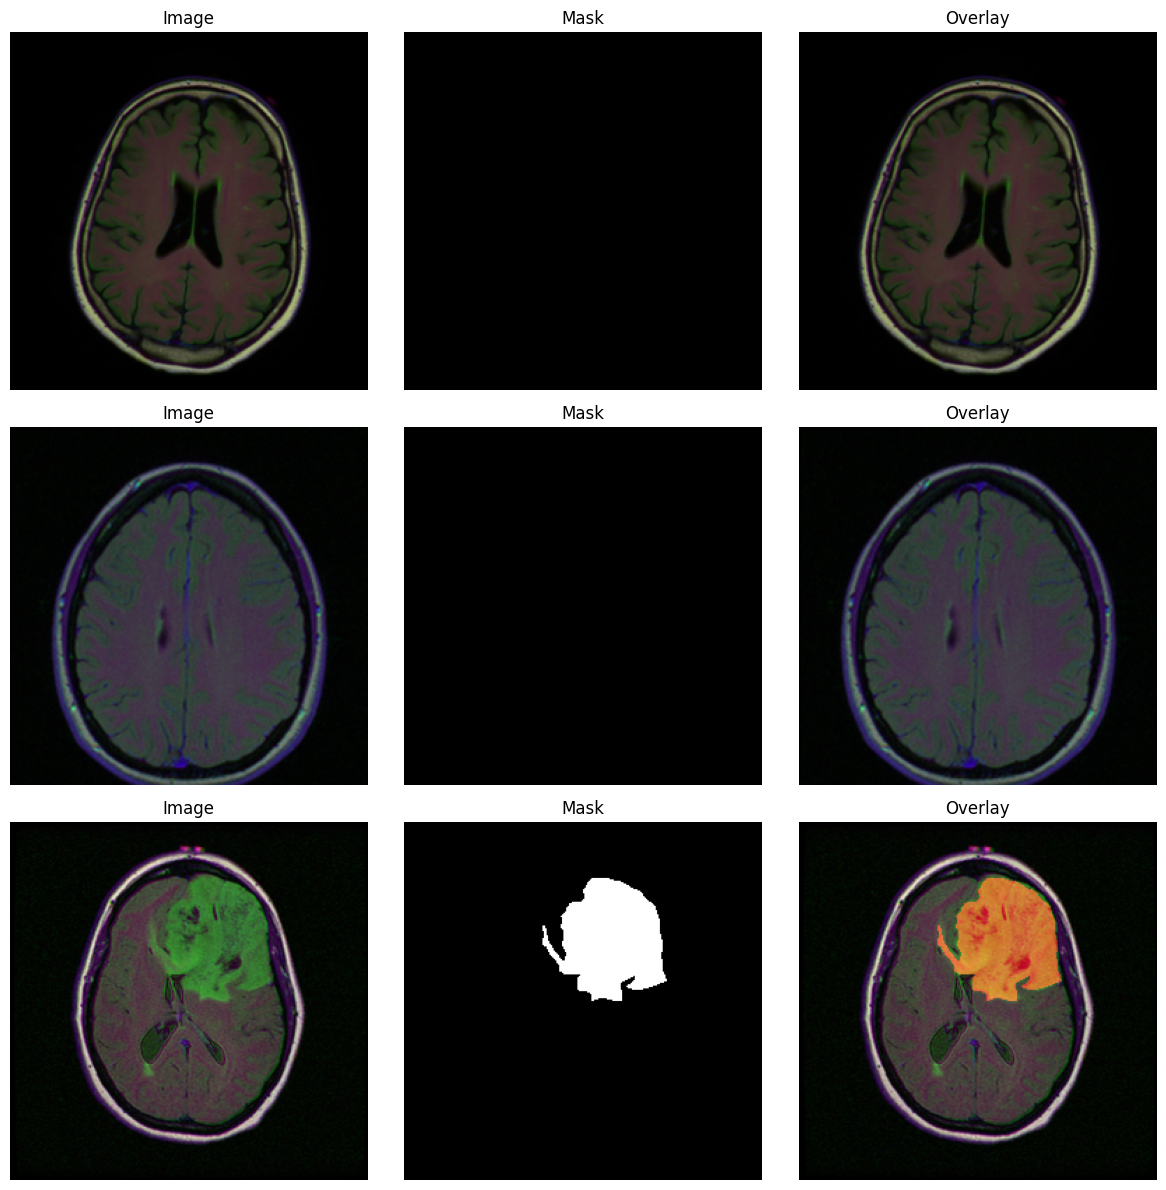

In [7]:
#6. 可视化检查 
def show_sample(ds, n=3):
    plt.figure(figsize=(12, 4*n))
    for i in range(n):
        img, mask = ds[random.randrange(len(ds))]
        img_np = img.permute(1,2,0).numpy()
        mask_np = mask.squeeze(0).numpy()

        # overlay
        overlay = img_np.copy()
        overlay[..., 0] = np.clip(overlay[..., 0] + mask_np * 0.6, 0, 1)

        ax1 = plt.subplot(n, 3, i*3+1); ax1.imshow(img_np); ax1.set_title("Image"); ax1.axis("off")
        ax2 = plt.subplot(n, 3, i*3+2); ax2.imshow(mask_np, cmap="gray"); ax2.set_title("Mask"); ax2.axis("off")
        ax3 = plt.subplot(n, 3, i*3+3); ax3.imshow(overlay); ax3.set_title("Overlay"); ax3.axis("off")
    plt.tight_layout()
    plt.show()

show_sample(train_ds, n=3)

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MultiScaleFeaturePyramidBayes(nn.Module):
    """
    输入:
      f_128: [B, C1, 128, 128]
      f_64 : [B, C2,  64,  64]
      f_32 : [B, C3,  32,  32]
    输出:
      p_128_ds, p_64_ds, p_32_ds: [B, out_ch, 128, 128]
      p_fused: [B, out_ch, 128, 128]
      w: [B, 3, 128, 128]  (每个尺度的融合权重，可用于可视化/写论文)
    """
    def __init__(self, c_128, c_64, c_32, out_ch=32):
        super().__init__()

        # 1x1 投影到统一通道
        self.proj_128 = nn.Conv2d(c_128, out_ch, kernel_size=1)
        self.proj_64  = nn.Conv2d(c_64,  out_ch, kernel_size=1)
        self.proj_32  = nn.Conv2d(c_32,  out_ch, kernel_size=1)

        # 可选：平滑（比你原来 downsample_* 更有意义）
        self.smooth_128 = nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1)
        self.smooth_64  = nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1)
        self.smooth_32  = nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1)

        # “贝叶斯启发”：为每个尺度预测 log variance（越大表示越不确定）
        # 输出 1 个通道的 logvar map
        self.logvar_128 = nn.Conv2d(out_ch, 1, kernel_size=3, padding=1)
        self.logvar_64  = nn.Conv2d(out_ch, 1, kernel_size=3, padding=1)
        self.logvar_32  = nn.Conv2d(out_ch, 1, kernel_size=3, padding=1)

        # 融合后再做一次整合
        self.fuse = nn.Sequential(
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, f_128, f_64, f_32):
        # 1) 投影
        p128 = self.smooth_128(self.proj_128(f_128))  # [B,out,128,128]
        p64  = self.smooth_64(self.proj_64(f_64))     # [B,out,64,64]
        p32  = self.smooth_32(self.proj_32(f_32))     # [B,out,32,32]

        # 2) 全部对齐到 128x128
        p128_ds = p128
        p64_ds  = F.interpolate(p64, size=(128, 128), mode="bilinear", align_corners=False)
        p32_ds  = F.interpolate(p32, size=(128, 128), mode="bilinear", align_corners=False)

        # 3) 预测每尺度不确定性 logvar -> precision = exp(-logvar)
        lv128 = self.logvar_128(p128_ds)  # [B,1,128,128]
        lv64  = self.logvar_64(p64_ds)
        lv32  = self.logvar_32(p32_ds)

        # precision 越大 => 越可信
        prec128 = torch.exp(-lv128)
        prec64  = torch.exp(-lv64)
        prec32  = torch.exp(-lv32)

        # 归一化权重（避免爆炸）
        prec_sum = prec128 + prec64 + prec32 + 1e-8
        w128 = prec128 / prec_sum
        w64  = prec64  / prec_sum
        w32  = prec32  / prec_sum

        # 4) 融合
        p_fused = w128 * p128_ds + w64 * p64_ds + w32 * p32_ds
        p_fused = self.fuse(p_fused)

        # 权重堆起来，方便你可视化/写 ablation
        w = torch.cat([w128, w64, w32], dim=1)  # [B,3,128,128]

        return p128_ds, p64_ds, p32_ds, p_fused, w

In [9]:
#8. Loss & 指标（Dice + IoU + BCEWithLogits）
@torch.no_grad()
def iou_from_logits(logits, targets, threshold=0.5, eps=1e-7):
    """
    logits:  [B,1,H,W] raw logits
    targets: [B,1,H,W] 0/1
    return: mean IoU over batch
    """
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    inter = (preds * targets).sum(dim=(2,3))
    union = preds.sum(dim=(2,3)) + targets.sum(dim=(2,3)) - inter

    iou = (inter + eps) / (union + eps)
    return iou.mean()

def dice_coef_from_logits(logits, targets, eps=1e-7):
    # logits: [B,1,H,W], targets: [B,1,H,W]
    probs = torch.sigmoid(logits)
    probs = (probs > 0.5).float()
    inter = (probs * targets).sum(dim=(2,3))
    union = probs.sum(dim=(2,3)) + targets.sum(dim=(2,3))
    dice = (2*inter + eps) / (union + eps)
    return dice.mean()

class DiceLoss(nn.Module):
    def __init__(self, eps=1e-7):
        super().__init__()
        self.eps = eps
    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        inter = (probs * targets).sum(dim=(2,3))
        union = probs.sum(dim=(2,3)) + targets.sum(dim=(2,3))
        dice = (2*inter + self.eps) / (union + self.eps)
        return 1 - dice.mean()

bce = nn.BCEWithLogitsLoss()
dice_loss = DiceLoss()

def total_loss(logits, targets):
    return 0.5 * bce(logits, targets) + 0.5 * dice_loss(logits, targets)

In [10]:
#9. DataLoader & Optimizer
train_loader = DataLoader(
    train_ds, batch_size=cfg.batch_size, shuffle=True,
    num_workers=cfg.num_workers, pin_memory=True, drop_last=True
)
val_loader = DataLoader(
    val_ds, batch_size=cfg.batch_size, shuffle=False,
    num_workers=cfg.num_workers, pin_memory=True
)

optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.epochs)

NameError: name 'model' is not defined

In [ ]:
#10. 训练与验证循环
from tqdm import tqdm

@torch.no_grad()
def validate(model, loader):
    model.eval()
    losses, dices, ious = [], [], []
    for imgs, masks in loader:
        imgs = imgs.to(device)
        masks = masks.to(device)

        logits = model(imgs)
        loss = total_loss(logits, masks).item()

        dice = dice_coef_from_logits(logits, masks).item()
        iou  = iou_from_logits(logits, masks).item()

        losses.append(loss)
        dices.append(dice)
        ious.append(iou)

    return float(np.mean(losses)), float(np.mean(dices)), float(np.mean(ious))

def train_one_epoch(model, loader):
    model.train()
    losses = []
    for imgs, masks in tqdm(loader, leave=False):
        imgs = imgs.to(device)
        masks = masks.to(device)

        logits = model(imgs)
        loss = total_loss(logits, masks)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
    return float(np.mean(losses))

best_val_dice = -1.0
history = []

for epoch in range(1, cfg.epochs+1):
    tr_loss = train_one_epoch(model, train_loader)
    val_loss, val_dice, val_iou = validate(model, val_loader)
    scheduler.step()

    history.append((epoch, tr_loss, val_loss, val_dice, val_iou))

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss {tr_loss:.4f} | "
        f"val_loss {val_loss:.4f} | "
        f"val_dice {val_dice:.4f} | "
        f"val_iou {val_iou:.4f}"
    )

    # 保存最好模型（仍按 dice 选 best）
    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save(model.state_dict(), "best_unet_aspp.pt")
        print("  ✅ saved best model")

Epoch 01 | train_loss 0.3070 | val_loss 0.3782 | val_dice 0.6909 | val_iou 0.6500
  ✅ saved best model


Epoch 02 | train_loss 0.3074 | val_loss 0.3719 | val_dice 0.7170 | val_iou 0.6785
  ✅ saved best model


Epoch 03 | train_loss 0.3065 | val_loss 0.3664 | val_dice 0.6855 | val_iou 0.6470


Epoch 04 | train_loss 0.3028 | val_loss 0.3683 | val_dice 0.6915 | val_iou 0.6516


Epoch 05 | train_loss 0.3013 | val_loss 0.3670 | val_dice 0.7456 | val_iou 0.7060
  ✅ saved best model


...

Epoch 16 | train_loss 0.2834 | val_loss 0.3666 | val_dice 0.7706 | val_iou 0.7326


Epoch 17 | train_loss 0.2826 | val_loss 0.3727 | val_dice 0.7830 | val_iou 0.7443


Epoch 18 | train_loss 0.2823 | val_loss 0.3700 | val_dice 0.7917 | val_iou 0.7539


Epoch 19 | train_loss 0.2812 | val_loss 0.3699 | val_dice 0.7956 | val_iou 0.7577


Epoch 20 | train_loss 0.2813 | val_loss 0.3699 | val_dice 0.8019 | val_iou 0.7643


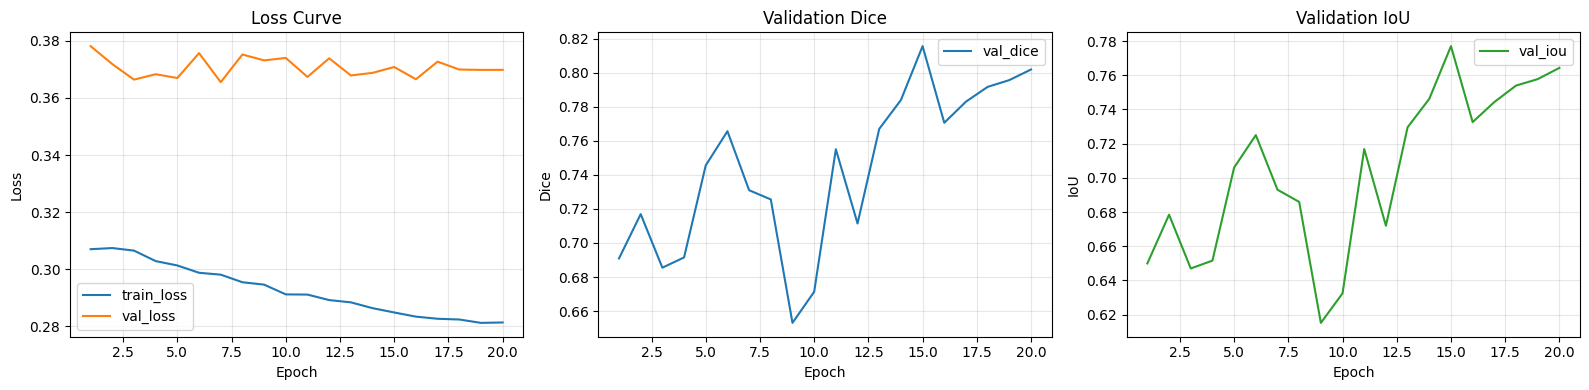

In [ ]:
# 11. 训练曲线（Loss / Dice / IoU）

epochs     = [h[0] for h in history]
tr_losses  = [h[1] for h in history]
val_losses = [h[2] for h in history]
val_dices  = [h[3] for h in history]
val_ious   = [h[4] for h in history]

plt.figure(figsize=(16,4))

# --- Loss ---
plt.subplot(1,3,1)
plt.plot(epochs, tr_losses, label="train_loss")
plt.plot(epochs, val_losses, label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.grid(alpha=0.3)

# --- Dice ---
plt.subplot(1,3,2)
plt.plot(epochs, val_dices, label="val_dice", color="tab:blue")
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.title("Validation Dice")
plt.legend()
plt.grid(alpha=0.3)

# --- IoU ---
plt.subplot(1,3,3)
plt.plot(epochs, val_ious, label="val_iou", color="tab:green")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.title("Validation IoU")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

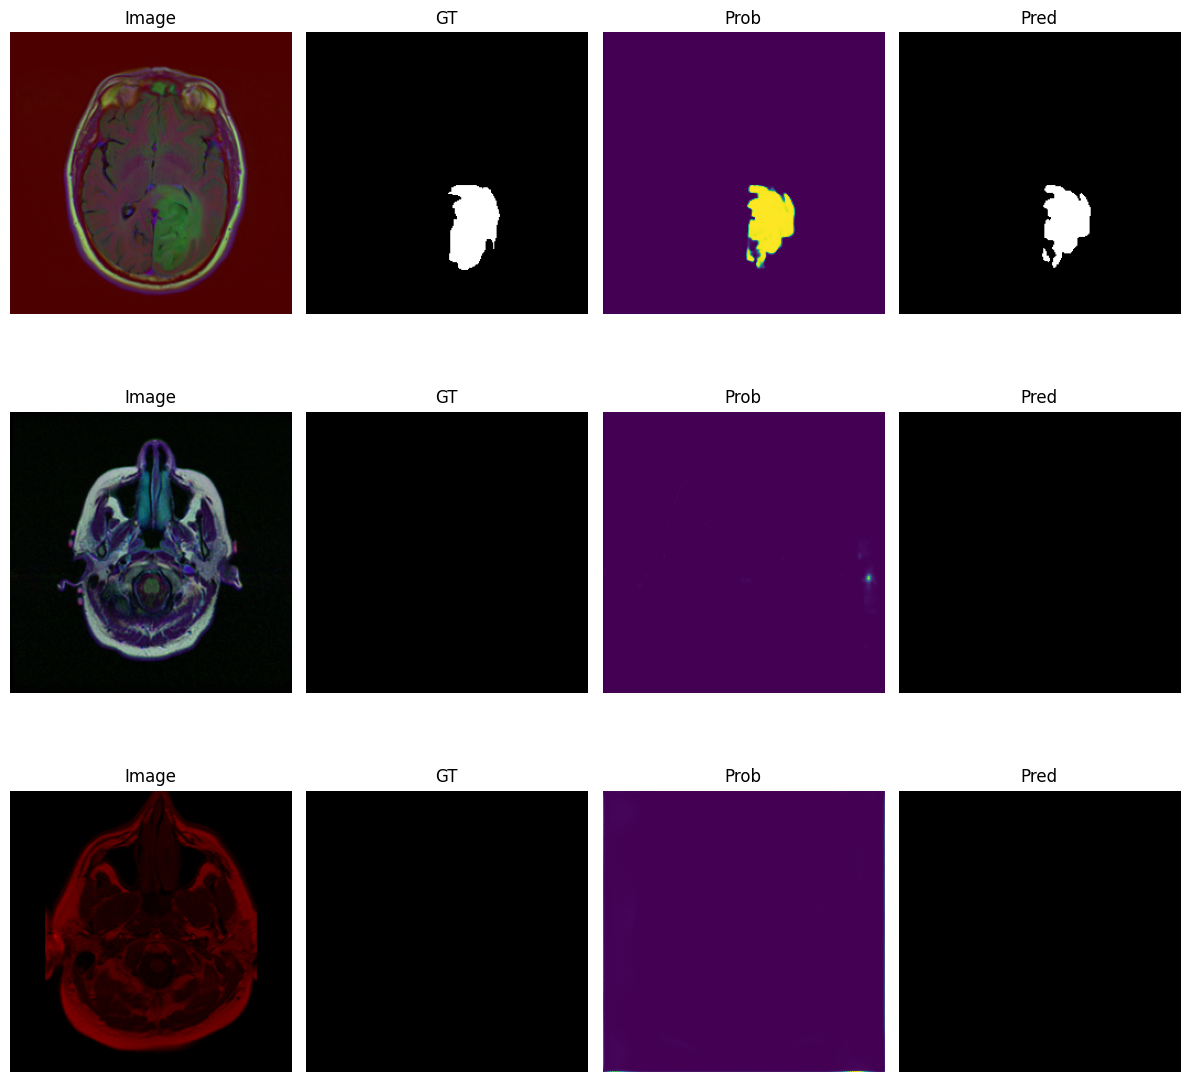

In [ ]:
#12. 可视化预测结果（验证集随机抽样）
@torch.no_grad()
def predict_one(model, img):
    model.eval()
    img = img.unsqueeze(0).to(device)
    logits = model(img)
    prob = torch.sigmoid(logits)[0,0].cpu().numpy()
    pred = (prob > 0.5).astype(np.uint8)
    return prob, pred

def show_preds(ds, n=3):
    model.load_state_dict(torch.load("best_unet_aspp.pt", map_location=device))
    plt.figure(figsize=(12, 4*n))
    for i in range(n):
        img, mask = ds[random.randrange(len(ds))]
        prob, pred = predict_one(model, img)

        img_np = img.permute(1,2,0).numpy()
        gt = mask.squeeze(0).numpy()

        ax1 = plt.subplot(n, 4, i*4+1); ax1.imshow(img_np); ax1.set_title("Image"); ax1.axis("off")
        ax2 = plt.subplot(n, 4, i*4+2); ax2.imshow(gt, cmap="gray"); ax2.set_title("GT"); ax2.axis("off")
        ax3 = plt.subplot(n, 4, i*4+3); ax3.imshow(prob); ax3.set_title("Prob"); ax3.axis("off")
        ax4 = plt.subplot(n, 4, i*4+4); ax4.imshow(pred, cmap="gray"); ax4.set_title("Pred"); ax4.axis("off")
    plt.tight_layout()
    plt.show()

show_preds(val_ds, n=3)

In [ ]:
#13. 在 Test set 上评估（Dice）
test_loader = DataLoader(
    test_ds, batch_size=cfg.batch_size, shuffle=False,
    num_workers=cfg.num_workers, pin_memory=True
)

model.load_state_dict(torch.load("best_unet_aspp.pt", map_location=device))

test_loss, test_dice, test_iou = validate(model, test_loader)
print(f"TEST | loss {test_loss:.4f} | dice {test_dice:.4f} | iou {test_iou:.4f}")

TEST | loss 0.3751 | dice 0.8054 | iou 0.7738
